In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind,pearsonr

In [50]:
# Read CSV files into a DataFrame

train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

In [51]:
train_df.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


### Analyse Univariée

In [52]:


# Statistiques descriptives pour les variables numériques
train_df.describe()



,ID,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,143579.000000,1.435790e+05,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000
mean,82521.171097,1.569202e+07,656.411704,38.144476,5.018408,55533.640642,1.553932,0.754107,0.496800,112530.072465,0.212078
std,47650.353367,7.142049e+04,80.210361,8.871711,2.807027,62822.616346,0.546754,0.430617,0.499991,50301.718378,0.408781
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41259.500000,1.563299e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74580.800000,0.000000
50%,82485.000000,1.569018e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117931.100000,0.000000
75%,123793.500000,1.575685e+07,710.000000,42.000000,7.000000,119948.090000,2.000000,1.000000,1.000000,155149.685000,0.000000
max,165033.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


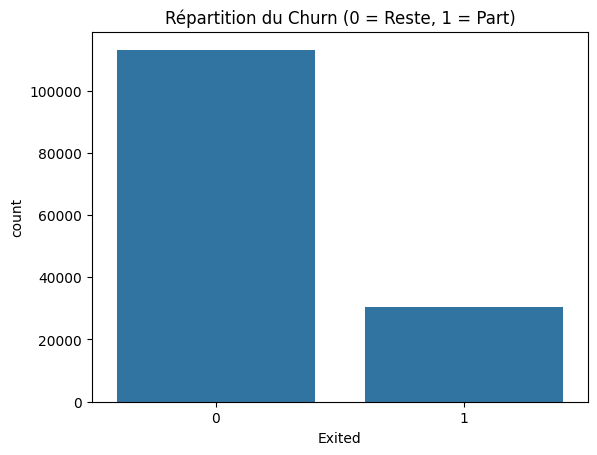

In [53]:
# Distribution de la variable cible (Exited)
sns.countplot(x='Exited', data=train_df)
plt.title('Répartition du Churn (0 = Reste, 1 = Part)')
plt.show()

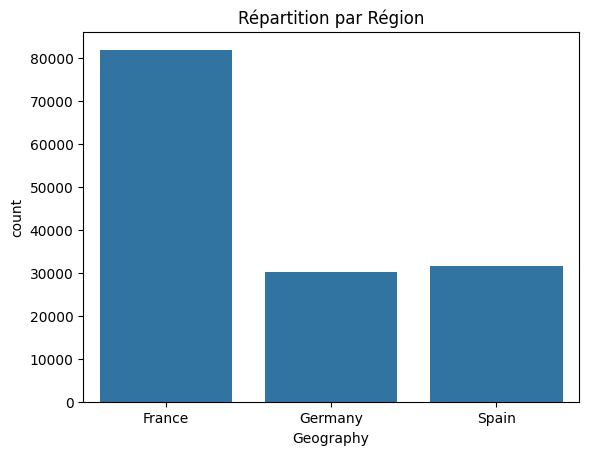

In [54]:
# Distribution de la vvariable geographique (Geography)
sns.countplot(x='Geography', data=train_df)
plt.title('Répartition par Région')
plt.show()


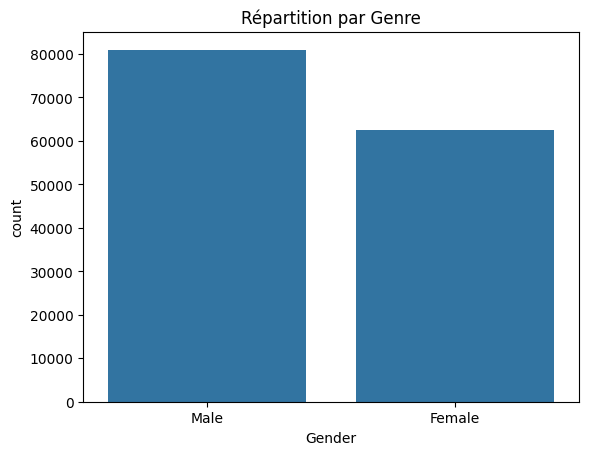

In [55]:
# Distribution de la variable gender
sns.countplot(x='Gender', data=train_df)
plt.title('Répartition par Genre')
plt.show()


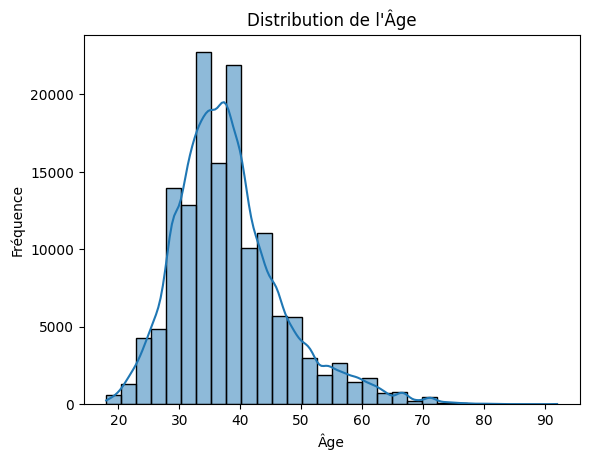

In [56]:
# Distribution de la variable Age
sns.histplot(train_df['Age'], bins=30, kde=True)
plt.title('Distribution de l\'Âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

##### Analyse de la Distribution

Asymétrie Positive (Skewness à droite) : La queue de la distribution s'étire vers la droite (les âges élevés). Cela signifie qu'une minorité de clients seniors qui s'étend jusqu'à 90 ans.

##### Identification de la "Cible" Principale

Le Coeur de Cible : Le pic de fréquence se situe entre 30 et 40 ans. C'est la période de la vie où les clients sont généralement les plus actifs financièrement (prêts immobiliers, début d'épargne sérieuse, vie de famille).

Concentration : On voit une montée rapide à partir de 25 ans et une chute progressive après 45 ans.



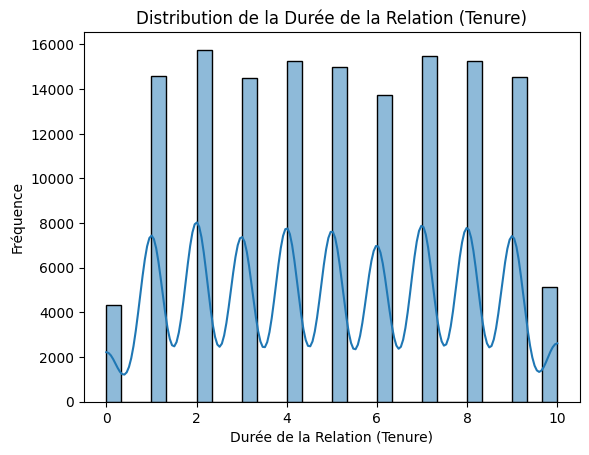

In [57]:
# Distribution de la variable Tenure en années
sns.histplot(train_df['Tenure'], bins=30, kde=True)
plt.title('Distribution de la Durée de la Relation (Tenure)')
plt.xlabel('Durée de la Relation (Tenure)')
plt.ylabel('Fréquence')
plt.show()


### Analyse Discrète-Discrète

Pourcentage de Churn par Genre :
 Exited          0          1
Gender                      
Female  71.930749  28.069251
Male    84.098263  15.901737


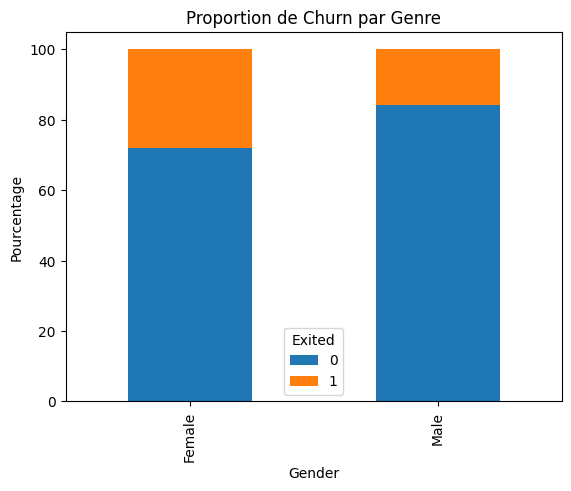

In [58]:
# Relation Genre vs Exited
gender_churn = pd.crosstab(train_df['Gender'], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Genre :\n", gender_churn)

# Visualisation
gender_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Genre')
plt.show()

Pourcentage de Churn par Région :
 Exited             0          1
Geography                      
France     83.455047  16.544953
Germany    61.973094  38.026906
Spain      82.733950  17.266050


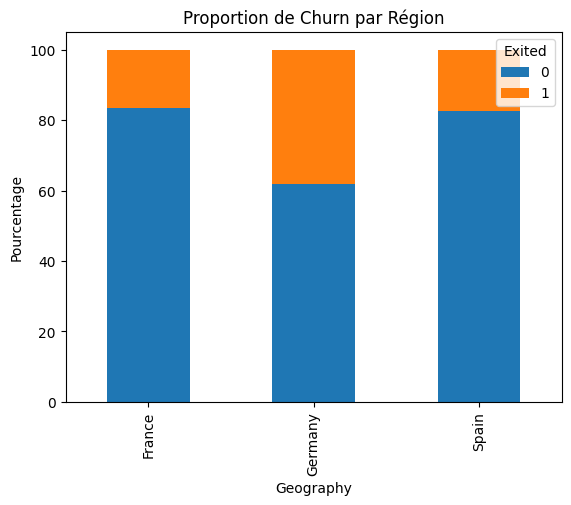

In [59]:
# Relation Geography vs Exited
geography_churn = pd.crosstab(train_df['Geography'], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Région :\n", geography_churn)

# Visualisation
geography_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Région')
plt.show()

Pourcentage de Churn par Région et Genre :
 Exited                    0          1
Geography Gender                      
France    Female  77.421581  22.578419
          Male    87.909988  12.090012
Germany   Female  53.510304  46.489696
          Male    69.645345  30.354655
Spain     Female  77.310054  22.689946
          Male    86.790991  13.209009


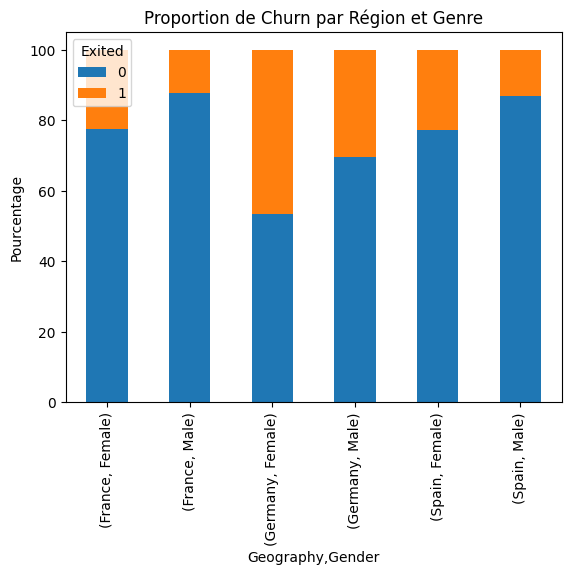

In [60]:
# Relation Geography et Gender vs Exited
geo_gender_churn = pd.crosstab([train_df['Geography'], train_df['Gender']], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Région et Genre :\n", geo_gender_churn)


# Visualisation
geo_gender_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Région et Genre')
plt.show()




Les femmes en Allemagne présentent le taux de churn le plus élevé de tout le dataset (la barre orange dépasse les 45%). C'est presque une chance sur deux de perdre la cliente.

Les hommes en Allemagne ont également un taux de départ très élevé (environ 30%), bien supérieur aux hommes des autres pays.

Hypothèse métier : Il y a peut-être une forte concurrence bancaire en Allemagne ou un produit spécifique qui ne convient pas à ce marché.

##### L'impact du Genre (Femmes vs Hommes)
On observe une tendance constante dans les trois pays :

Dans chaque région (France, Allemagne, Espagne), la proportion de partants (orange) est systématiquement plus élevée chez les femmes que chez les hommes.

Conclusion technique : La variable Gender est un prédicteur fort. Votre modèle de Machine Learning devra absolument lui accorder de l'importance.

##### Les zones de stabilité : France et Espagne
La France et l'Espagne ont des profils de churn assez similaires.

Les hommes en France et en Espagne sont les segments les plus fidèles (le churn y est le plus bas, aux alentours de 10-15%).

### Analyse Discrète-Continue

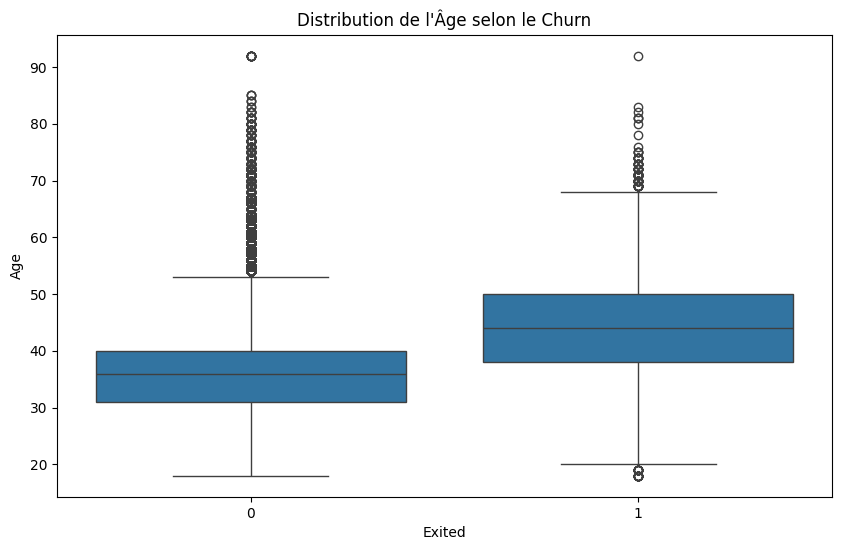

In [61]:
# Relation Age (Continue) vs Exited (Discrète)
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited', y='Age', data=train_df)
plt.title('Distribution de l\'Âge selon le Churn')
plt.show()

##### Différence de Médiane
Clients fidèles (0) : La médiane de l'âge se situe autour de 36 ans.

Clients qui partent (1) : La médiane est nettement plus élevée, aux alentours de 44 ans.

Interprétation : Les clients qui ferment leur compte sont globalement plus âgés que ceux qui restent.

##### L'Intervalle Interquartile
La boîte des "partants" (1) est située plus haut sur l'axe des ordonnées.

75% des clients qui restent ont moins de 40 ans, alors que près de 50% des clients qui partent ont plus de 44 ans.

Cela confirme que l'âge est un prédicteur majeur : plus un client vieillit dans ce dataset, plus sa probabilité de churn semble augmenter.

##### Les Valeurs Aberrantes (Les points isolés en haut)
On observe de nombreux "outliers" (valeurs aberrantes) chez les clients qui restent ($Exited=0$), s'étendant de 55 à plus de 90 ans.
Signification : Bien que la banque ait quelques clients très âgés et fidèles, ils sont statistiquement rares par rapport à la masse.

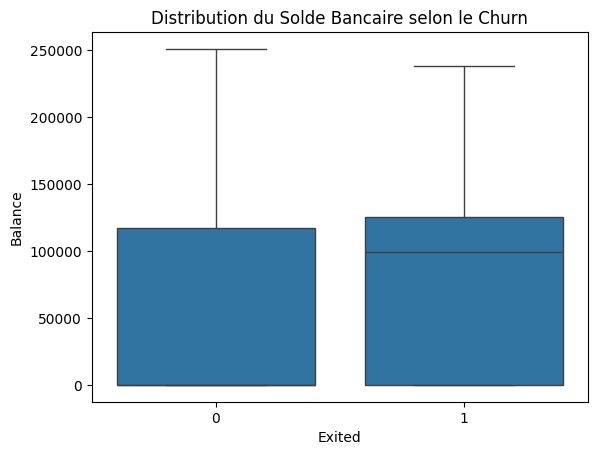

In [62]:
# Relation Solde (Continue) vs Exited (Discrète)
sns.boxplot(x='Exited', y='Balance', data=train_df)
plt.title('Distribution du Solde Bancaire selon le Churn')
plt.show()

##### bservations sur le Solde (Balance)
Médiane plus élevée pour le Churn : La ligne centrale de la boîte pour les clients qui partent ($Exited = 1$) est nettement supérieure à celle des clients qui restent ($Exited = 0$). 
Cela suggère que les clients ayant des soldes plus élevés ont une tendance plus forte à quitter la banque.

La "masse" à zéro : On remarque que pour les deux groupes, la base de la boîte (le minimum ou le premier quartile) touche le $0$. Cela confirme qu'une grande partie des clients de la banque ont un solde nul ou très faible.

Dispersion : La boîte des clients qui partent est plus compacte vers le haut, indiquant que le churn se concentre chez des clients ayant un capital significatif (entre $100\ 000$ et $125\ 000$ unités).

#### Hypothèse 
 Ces clients cherchent peut-être de meilleurs taux d'intérêt ou des placements plus avantageux ailleurs.

### Analyse Continue-Continue

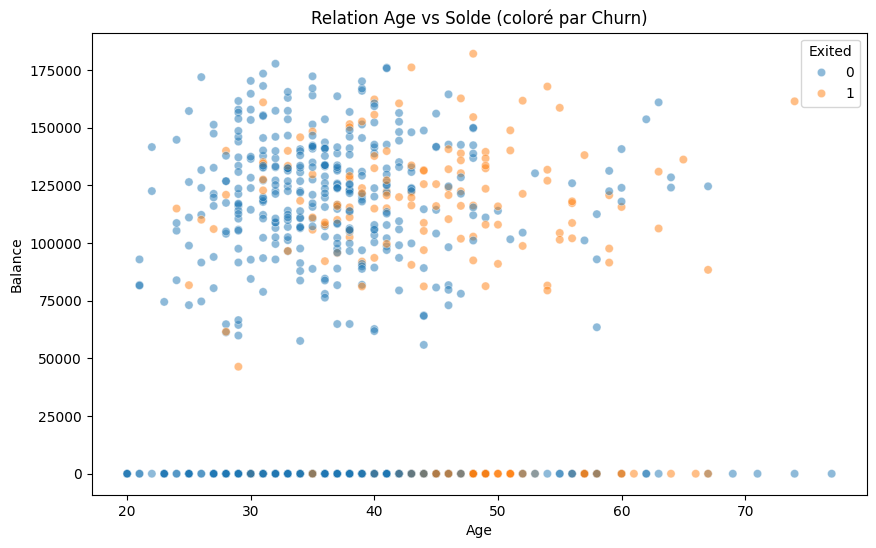

In [63]:
# Relation Age vs Solde
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=train_df.sample(1000), alpha=0.5)
plt.title('Relation Age vs Solde (coloré par Churn)')
plt.show()

##### Analyse de la Corrélation (Age vs Solde)
Absence de tendance linéaire : On ne voit pas de "ligne" se dessiner. Cela signifie que le solde bancaire n'est pas directement lié à l'âge du client. 
On trouve des clients riches  aussi bien chez les jeunes (20-30 ans) que chez les seniors.
La ligne horizontale à zéro : On voit une concentration de points tout en bas du graphique. 
Ce sont les clients avec un solde nul. 
Notez que beaucoup de ces points sont orange (churn) à partir de 40-45 ans.
 
Concentration du Churn (Points Orange)La "zone de danger" : Les points orange sont beaucoup plus denses sur la partie droite du graphique, particulièrement entre 40 et 60 ans.
L'effet combiné : On remarque que pour les clients de plus de 45 ans, le départ arrive peu importe que le solde soit de $0$ ou de $150\ 000$. 


Cependant, dans la tranche 30-40 ans, les départs semblent plus fréquents chez ceux qui ont un solde élevé (haut du nuage). Densité des Clients Fidèles (Points Bleus)Les points bleus sont massivement concentrés chez les moins de 40 ans, avec une grande variété de soldes. C'est le segment stable de la banque.

### Analyse Multivariée

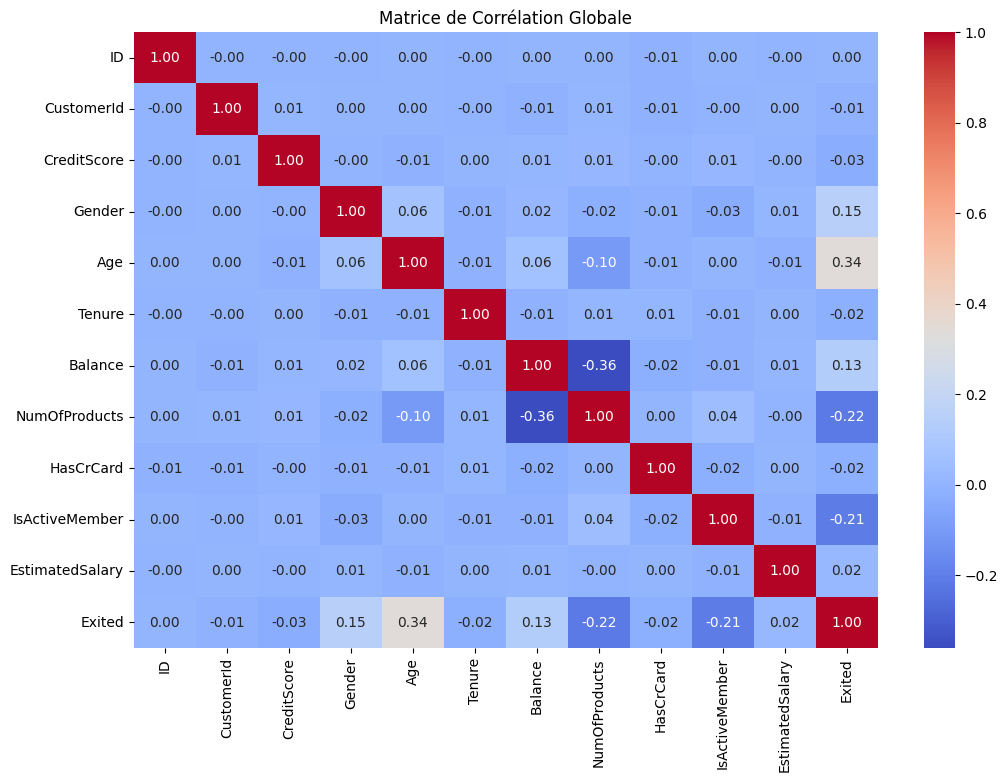

In [64]:
# Matrice de corrélation
plt.figure(figsize=(12, 8))
# On encode temporairement pour inclure Gender dans la matrice
df_corr = train_df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Female': 1, 'Male': 0})
numeric_cols = df_corr.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation Globale')
plt.show()

##### La Variable Cible : Exited (Ligne/Colonne du bas)
C'est ici que vous déterminez ce qui cause réellement le départ des clients.
Âge ($0.34$) : C'est la corrélation positive la plus forte. Cela confirme mathématiquement que plus l'âge augmente, plus le risque de churn augmente.
IsActiveMember ($-0.21$) : Corrélation négative significative. Cela signifie qu'être un membre actif réduit fortement la probabilité de partir.
NumOfProducts ($-0.22$) : Plus le client possède de produits, moins il risque de partir (jusqu'à un certain seuil, car une corrélation peut être complexe).
Gender ($0.15$) et Balance ($0.13$) : Ces variables ont un impact modéré mais non négligeable.

In [ ]:
# supprimer les colonnes HasCrCard EstimatedSalary ID  CustomerId 
# car ils n'apportent pas d'information pertinente pour la prédiction du churn

train_df = train_df.drop(['HasCrCard', 'EstimatedSalary', 'ID', 'CustomerId','Surname'], axis=1)
train_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Exited
0,627,France,Male,28.0,7,131694.04,1,1.0,0
1,597,France,Male,34.0,2,0.00,2,1.0,0
2,724,France,Male,39.0,7,0.00,2,1.0,0
3,663,Germany,Female,56.0,5,118577.24,3,0.0,1
4,627,France,Female,33.0,5,0.00,2,1.0,0


## Tester des hypothèses

#### Hypothèse : 
Est-ce que le pays de résidence (Geography) influence réellement le fait de quitter la banque (Exited) ?
##### H0 : Le pays et le churn sont indépendants (le pays n'a pas d'influence).
##### Alpha : 0.05 (Seuil standard de 5%).

In [ ]:
# Test du Chi2 d'indépendance entre la variable cible Exited et geography

contingency_table = pd.crosstab(train_df['Geography'], train_df['Exited'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"p-value du test Chi2 : {p:.10f}")

if p < 0.05:
    print("Conclusion : On rejette H0. Le pays a une influence significative sur le churn.")
else:
    print("Conclusion : On ne rejette pas H0. Pas de preuve d'influence du pays.")  


p-value du test Chi2 : 0.0000000000
Conclusion : On rejette H0. Le pays a une influence significative sur le churn.


#### Hypothèse 
Les clients qui partent ont-ils un solde bancaire (Balance) moyen différent de ceux qui restent ?
##### H0 : La moyenne des soldes est la même pour les deux groupes.
##### Condition : Nous avons plus de 30 points (TCL), donc le test est valide.

In [70]:
# Test de Student à 2 échantillons Balance et Exited
  
churned_balance = train_df[train_df['Exited'] == 1]['Balance']
not_churned_balance = train_df[train_df['Exited'] == 0]['Balance']
t_stat, p_value = ttest_ind(churned_balance, not_churned_balance, equal_var=False)
print(f"p-value du test de Student : {p_value:.10f}")

if p_value < 0.05:
    print("Conclusion : On rejette H0. Le solde a une influence significative sur le churn.")
else:
    print("Conclusion : On ne rejette pas H0. Pas de preuve d'influence du solde.")

p-value du test de Student : 0.0000000000
Conclusion : On rejette H0. Le solde a une influence significative sur le churn.


#### Hypothèse 
 Existe-t-il une corrélation entre l'âge du client et son score de crédit ?
##### H0: Il n'y a pas de corrélation entre l'âge et le score de crédit.


In [73]:
# Test de Pearson entre Age et score de crédit (CreditScore)
age = train_df['Age']
credit_score = train_df['CreditScore']
corr_coef, p_value = pearsonr(age, credit_score)
print(f"Coefficient de corrélation de Pearson : {corr_coef:.4f}")
print(f"p-value du test de Pearson : {p_value:.10f}")

if p_value < 0.05:
    print("Conclusion : On rejette H0. L'âge a une influence significative sur le score de crédit.")
else:
    print("Conclusion : On ne rejette pas H0. Pas de preuve d'influence de l'âge sur le score de crédit.")

Coefficient de corrélation de Pearson : -0.0102
p-value du test de Pearson : 0.0001140029
Conclusion : On rejette H0. L'âge a une influence significative sur le score de crédit.
